In [45]:
import polars as pl
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc

from statistics import mean

In [2]:
DATASET_PATH = '../dataset/E066/'

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


# Load the data

In [4]:
E066_df = pl.read_parquet(os.path.join(DATASET_PATH, "E066_w_histone_pl.parquet"))

In [5]:
E066_df.head()

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [6]:
# Select X and y column
X = E066_df.select(pl.col('all_histone')).to_series().to_list()
y = E066_df.select(pl.col('label')).to_series().to_list()

In [7]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

In [8]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [9]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (6561, 5, 100) (6561,)
Validation set shape: (6542, 5, 100) (6542,)
Test set shape: (6542, 5, 100) (6542,)


In [10]:
# Convert numpy arrays to PyTorch tensors

X_train = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val = torch.from_numpy(X_val).float().unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test).float().unsqueeze(1).to(device)

y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

In [11]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
class DeepClassifier(nn.Module):
    def __init__(self, input_dim = [5, 100], out_channels = 50, conv_kernel_size = 10, max_pooling_kernel_size = 5):
        super(DeepClassifier, self).__init__()
        
        flatten_dim = out_channels * ((input_dim[1] - conv_kernel_size + 1) // max_pooling_kernel_size)

        self.conv = nn.Conv2d(1, out_channels, kernel_size=(input_dim[0], conv_kernel_size))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((1, max_pooling_kernel_size))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(flatten_dim, 625)
        self.linear2 = nn.Linear(625, 125)
        self.linear3 = nn.Linear(125, 2)
        self.softmax = nn.LogSoftmax(dim=1)
        

    def forward(self, x):
        # Stage 1: filter bank -> squashing -> max pooling
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        # Stage 2: standar 2-layer neural network        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        x = self.softmax(x)
        return x

In [118]:
model = DeepClassifier().to(device)
criterion = nn.NLLLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.001)
num_epochs = 100

# For tracking train and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []

# For saving the best model
best_val_metric = float('-inf')
best_model_path = 'best_model.pth'

In [119]:
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_true_labels.extend(labels.cpu().numpy())
        train_predicted_probs.extend(predicted.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_probs)
    
    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_probs = []
    
    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_true_labels.extend(labels.cpu().numpy())
            val_predicted_probs.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_metric = val_correct / len(val_loader)

    # Save the best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved with validation metric: {best_val_metric:.4f}")
    
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_auc_score = roc_auc_score(val_true_labels, val_predicted_probs)

    val_losses.append(round(avg_val_loss, 4))
    val_accuracies.append(round(val_accuracy, 2))
    val_aucs.append(round(val_auc_score, 2))
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} - '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, AUC: {val_auc_score:.2f}')
print("Training finished!")

New best model saved with validation metric: 16.0927
Epoch [1/100] - [TRAIN] Loss: 0.6422, Accuracy: 49.96%, AUC: 0.50 - [VAL] Loss: 0.6239, Accuracy: 50.43%, AUC: 0.50
New best model saved with validation metric: 22.2927
Epoch [2/100] - [TRAIN] Loss: 0.6138, Accuracy: 57.98%, AUC: 0.58 - [VAL] Loss: 0.6038, Accuracy: 69.86%, AUC: 0.70
New best model saved with validation metric: 24.3610
Epoch [3/100] - [TRAIN] Loss: 0.5879, Accuracy: 74.82%, AUC: 0.75 - [VAL] Loss: 0.5842, Accuracy: 76.34%, AUC: 0.76
New best model saved with validation metric: 24.6780
Epoch [4/100] - [TRAIN] Loss: 0.5714, Accuracy: 78.19%, AUC: 0.78 - [VAL] Loss: 0.5702, Accuracy: 77.33%, AUC: 0.77
New best model saved with validation metric: 24.9171
Epoch [5/100] - [TRAIN] Loss: 0.5636, Accuracy: 78.49%, AUC: 0.78 - [VAL] Loss: 0.5510, Accuracy: 78.08%, AUC: 0.78
Epoch [6/100] - [TRAIN] Loss: 0.5449, Accuracy: 78.89%, AUC: 0.79 - [VAL] Loss: 0.5495, Accuracy: 77.90%, AUC: 0.78
Epoch [7/100] - [TRAIN] Loss: 0.5337, A

In [91]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

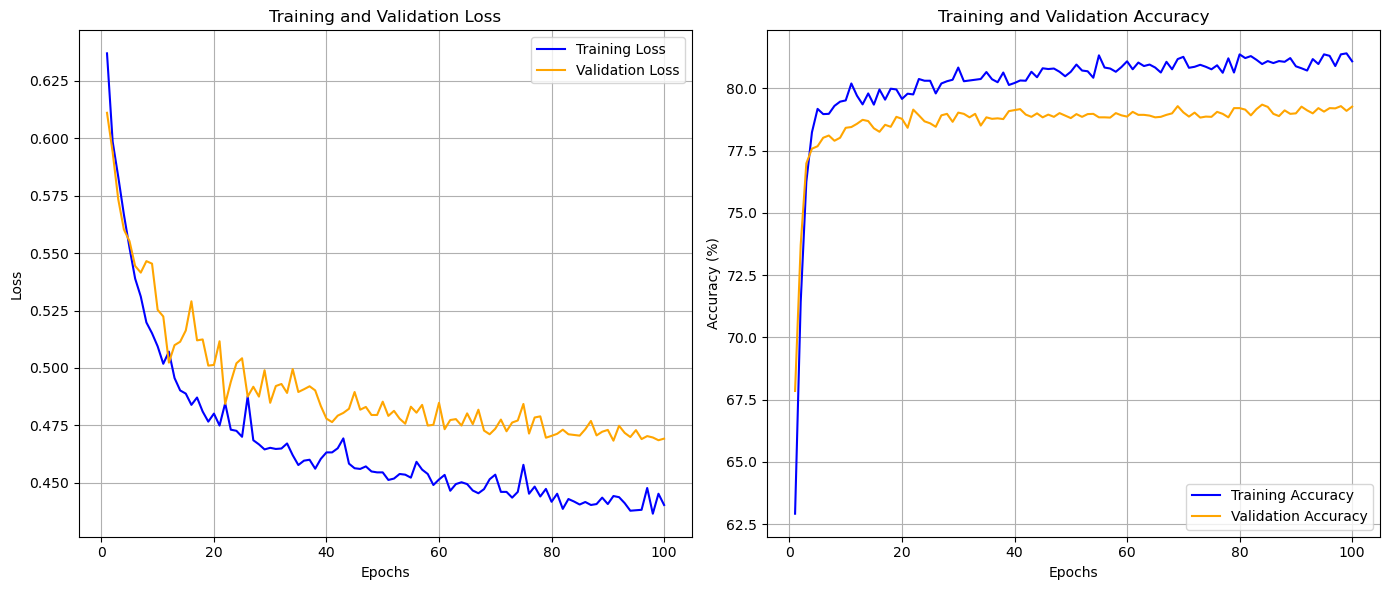

In [92]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

In [120]:
# Load the best model
best_model = DeepClassifier().to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        # probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
print(f"AUC Score on test set: {test_auc_score:.2f}")

Accuracy Score on test set: 80.54 %
AUC Score on test set: 0.81


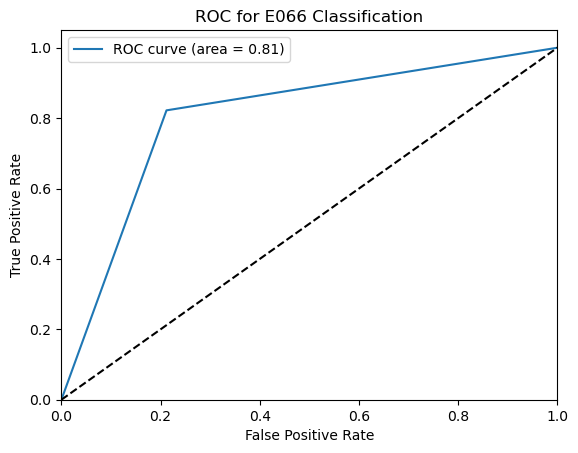

In [107]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for E066 Classification')
plt.legend()
plt.show()

In [108]:
# Create dataframe from array
experiment_results = {
    'train_loss': train_losses,
    'train_accuracy': train_accuracies,
    'train_auc': train_aucs,
    'val_loss': val_losses,
    'val_accuracy': val_accuracies,
    'val_auc': val_aucs
}

In [109]:
experiment_df = pl.DataFrame(experiment_results)

In [110]:
experiment_df.head()

train_loss,train_accuracy,train_auc,val_loss,val_accuracy,val_auc
f64,f64,f64,f64,f64,f64
0.637,62.92,0.63,0.6111,67.85,0.68
0.5986,71.42,0.71,0.594,73.71,0.74
0.5832,76.25,0.76,0.5734,76.99,0.77
0.5668,78.24,0.78,0.5603,77.58,0.78
0.5523,79.18,0.79,0.5552,77.68,0.78


In [111]:
experiment_df.write_csv(os.path.join(DATASET_PATH, 'experiments', 'all_histone.csv'))

In [112]:
def min_avg_max(lst):
    return round(min(lst), 2), round(sum(lst)/len(lst), 2), round(max(lst), 2)

In [113]:
train_loss_min, train_loss_avg, train_loss_max = min_avg_max(train_losses)
train_acc_min, train_acc_avg, train_acc_max = min_avg_max(train_accuracies)
train_auc_min, train_auc_avg, train_auc_max = min_avg_max(train_aucs)

print(f"{train_loss_min:.2f}, {train_loss_avg:.2f}, {train_loss_max:.2f}")
print(f"{train_acc_min}, {train_acc_avg}, {train_acc_max}")
print(f"{train_auc_min}, {train_auc_avg}, {train_auc_max}")

0.44, 0.47, 0.64
62.92, 80.22, 81.41
0.63, 0.8, 0.81


In [116]:
val_loss_min, val_loss_avg, val_loss_max = min_avg_max(val_losses)
val_acc_min, val_acc_avg, val_acc_max = min_avg_max(val_accuracies)
val_auc_min, val_auc_avg, val_auc_max = min_avg_max(val_aucs)

print(f"{val_loss_min:.2f}, {val_loss_avg:.2f}, {val_loss_max:.2f}")
print(f"{val_acc_min}, {val_acc_avg}, {val_acc_max}")
print(f"{val_auc_min}, {val_auc_avg}, {val_auc_max}")

0.47, 0.49, 0.61
67.85, 78.67, 79.35
0.68, 0.79, 0.79


In [117]:
print(f"{round(test_acc_score, 2)}, {round(test_auc_score, 2)}")

80.51, 0.81
